In [77]:
import pandas as pd
import os
import os.path as osp
import numpy as np
from utils.call_number import classify_call_number
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

## Preprocessing

### Load data

In [78]:
data_folder = "data"
csv_filepath = "books_with_intro.csv"

df = xlsx_file = pd.read_csv(osp.join(data_folder, csv_filepath),
                             header=1)
print(df.columns)
print(f"# of books (Before preprocessing): {len(df)}")

Index(['bi_id', 'bi_isbn', 'bi_irn', 'bi_class', 'bi_price', 'bi_title',
       'bi_image', 'bi_content', 'bi_auther', 'bi_publisher',
       'bi_publisher_year', 'bi_site'],
      dtype='object')
# of books (Before preprocessing): 41041


In [79]:
selected_cols = ["bi_id", "bi_isbn", "bi_class", "bi_title", "bi_image", "bi_content", "bi_auther", "bi_publisher", "bi_publisher_year", "bi_site"]
df.replace(to_replace=["NULL", "null", "N/A", "na", "NaN", ""], value=np.nan, inplace=True)
df = df.dropna(subset=selected_cols).reset_index(drop=True)
print(f"# of books (After preprocessing): {len(df)}")

# of books (After preprocessing): 4723


In [80]:
df['category'] = df['bi_class'].apply(classify_call_number)

### Statistic Research

In [81]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [82]:
def token_statistic(token_counts):
    mean_tokens = token_counts.mean()
    std_tokens = token_counts.std()
    max_tokens = token_counts.max()
    min_tokens = token_counts.min()

    print(f"Mean number of tokens: {mean_tokens:.2f}")
    print(f"Standard deviation of tokens: {std_tokens:.2f}")
    print(f"Maximum number of tokens: {max_tokens}")
    print(f"Minimum number of tokens: {min_tokens}")

    # Optional: Plot histogram
    plt.figure(figsize=(8, 4))
    plt.hist(token_counts, bins=30, edgecolor='black')
    plt.title("Distribution of Token Counts per Row")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [83]:
model = SentenceTransformer('shibing624/text2vec-base-chinese')
tokenizer = model.tokenizer
max_tokens = 128
chunk_size = 128

In [84]:
def chunk_text(text, tokenizer, chunk_size=128):
    tokens = tokenizer.tokenize(text)
    chunks = ["".join(tokens[i:i+chunk_size]) for i in range(0, len(tokens), chunk_size)]
    return chunks

def count_tokens_after_chunking(text, tokenizer):
    chunks = chunk_text(text, tokenizer)
    return sum(len(tokenizer.tokenize(chunk)) for chunk in chunks)

Token indices sequence length is longer than the specified maximum sequence length for this model (5944 > 128). Running this sequence through the model will result in indexing errors


========== Token Count After Chunking ==========
Mean number of tokens: 1958.93
Standard deviation of tokens: 1012.47
Maximum number of tokens: 5968
Minimum number of tokens: 237


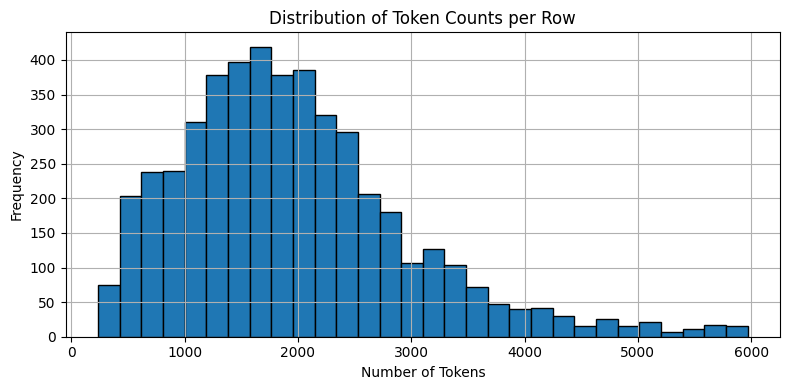

In [85]:
orig_token_counts = df['bi_content'].apply(lambda x: count_tokens_after_chunking(x, tokenizer))

print("========== Token Count After Chunking ==========")
token_statistic(orig_token_counts)
print("===============================================")

### Data Cleaning

In [86]:
import re
import unicodedata

def clean_basic(text):
    text = re.sub(r'<[^>]+>', '', text)  # remove HTML tags
    text = re.sub(r'\s+', ' ', text)     # normalize whitespace
    text = re.sub(r'[^\u4e00-\u9fffA-Za-z0-9.,!?，。！？（）()「」“”\'\"\-:：\n ]+', '', text)  # remove weird symbols
    return text.strip()

def normalize_width(text):
    return unicodedata.normalize('NFKC', text)

def remove_MARC(content):
    arr = content.split("001")
    if len(arr) > 1 and arr[0].strip():
        text = arr[0]
    else:
        text = content
    return text

In [87]:
def remove_exact_duplicates(text):
    sentences = text.split('。')  # Use Chinese period for segmentation
    seen = set()
    unique_sentences = []
    for s in sentences:
        s = s.strip()
        if s and s not in seen:
            unique_sentences.append(s)
            seen.add(s)
    return '。'.join(unique_sentences)

In [88]:
def clean_synopsis(text):
    text = normalize_width(text)
    text = clean_basic(text)
    text = remove_exact_duplicates(text)
    text = remove_MARC(text)

    return text

In [89]:
from tqdm import tqdm

tqdm.pandas()
contents = df['bi_content'].progress_apply(clean_synopsis)
# token_statistic(token_counts)

100%|██████████| 4723/4723 [00:00<00:00, 4991.25it/s]


Mean number of tokens: 1309.97
Standard deviation of tokens: 894.12
Maximum number of tokens: 5619
Minimum number of tokens: 4


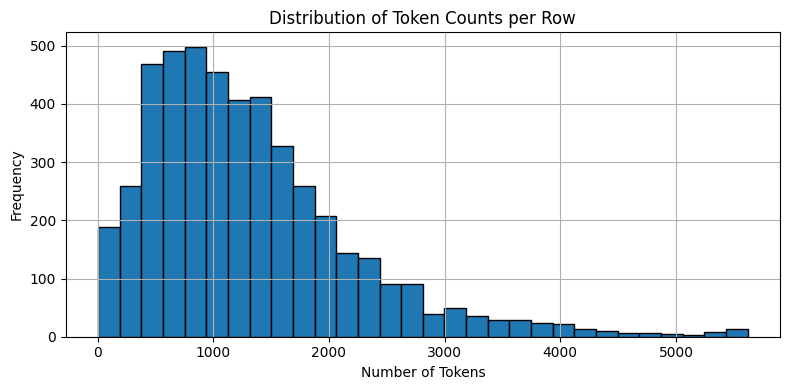

In [90]:
cleaned_token_counts = contents.apply(lambda x: count_tokens_after_chunking(x, tokenizer))
token_statistic(cleaned_token_counts)

In [91]:
df['bi_content'] = contents

In [92]:
saved_csv = "books_with_intro_cleaned.csv"
df.to_csv(osp.join(data_folder, saved_csv))
print(f"Cleaned data saved to: {osp.join(data_folder, saved_csv)}")

Cleaned data saved to: data/books_with_intro_cleaned.csv


## Get Embeddings

In [93]:
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

def plot_embeddings_plotly(embeddings, titles=None, labels=None, method='pca', title='Interactive Embedding Visualization'):
    # Convert to numpy if torch
    if hasattr(embeddings, 'detach'):
        embeddings = embeddings.detach().cpu().numpy()
    
    # Normalize embeddings if needed
    embeddings = normalize(embeddings)

    # Reduce to 2D
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        raise ValueError("method must be 'pca' or 'tsne'")
    
    reduced = reducer.fit_transform(embeddings)

    # Prepare dataframe for plotting
    df = pd.DataFrame(reduced, columns=['x', 'y'])
    if titles is not None:
        df['title'] = titles
    if labels is not None:
        df['label'] = labels

    # Plot
    fig = px.scatter(
        df,
        x='x',
        y='y',
        color='label' if labels is not None else None,
        hover_name='title' if titles is not None else None,
        title=title,
        width=1000,
        height=800
    )
    fig.show()

In [94]:
template = """
書名: {bi_title}
作者: {bi_auther}
大綱: {bi_content}
"""
param_dict = ["bi_title", "bi_auther", "bi_content"]

def build_book_text(row):
    return template.format(**{key: row.get(key, "") for key in param_dict})

book_texts = df.apply(build_book_text, axis=1).tolist()

In [95]:
all_chunked_texts = []

for text in book_texts:
    chunks = chunk_text(text, tokenizer, chunk_size)
    all_chunked_texts.append(chunks)

In [70]:
max_chunks = 8
embedding_dim = model.get_sentence_embedding_dimension()

final_embeddings = []

for chunks in tqdm(all_chunked_texts):
    selected = chunks[:max_chunks]
    while len(selected) < max_chunks:
        selected.append("")
    embeddings = model.encode(selected, convert_to_tensor=True)
    final_embeddings.append(torch.flatten(embeddings))

100%|██████████| 4723/4723 [50:44<00:00,  1.55it/s]


In [71]:
from sklearn.model_selection import train_test_split

all_embeddings = torch.stack(final_embeddings)
train_tensor, test_tensor = train_test_split(all_embeddings, test_size=0.2)

torch.save(all_embeddings, "all_embeddings.pt")
torch.save(train_tensor, "train_embeddings.pt")
torch.save(test_tensor, "test_embeddings.pt")

In [72]:
print(len(final_embeddings))
print(len(final_embeddings[0]))

4723
6144


In [73]:
reshaped_embeddings = all_embeddings.reshape(-1, 8, 768)
print(reshaped_embeddings.shape)

torch.Size([4723, 8, 768])


In [74]:
chunk_level_embeddings = reshaped_embeddings.view(-1, 768)
print(chunk_level_embeddings.shape)

torch.Size([37784, 768])


In [75]:
from sklearn.model_selection import train_test_split

train_tensor, test_tensor = train_test_split(chunk_level_embeddings, test_size=0.2)

torch.save(all_embeddings, "all_embeddings.pt")
torch.save(train_tensor, "train_embeddings.pt")
torch.save(test_tensor, "test_embeddings.pt")

In [96]:
all_embeddings = torch.load("all_embeddings.pt")
train_tensor = torch.load("train_embeddings.pt")
test_tensor = torch.load("test_embeddings.pt")

In [97]:
book_texts = df.apply(build_book_text, axis=1).tolist()

df['bi_content'].apply(lambda x: count_tokens_after_chunking(x, tokenizer))
book_embeddings = tokenizer(book_texts, max_length=2048, padding=True, truncation=True, return_tensors='pt')
book_embeddings = book_embeddings['input_ids']
book_embeddings = normalize(book_embeddings)

In [98]:
print(book_embeddings[0].shape)

(2048,)


In [99]:
print(all_embeddings.shape)
plot_embeddings_plotly(all_embeddings, titles=df['bi_title'], labels=df['category'], method='tsne')

torch.Size([4723, 6144])


## Train Autoencoder

### Autoencoder Class

In [100]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, bottleneck_dim):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, bottleneck_dim),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim),
        )
    
    def forward(self, input):
        encode =  self.encoder(input)
        decode = self.decoder(encode)

        return decode
    
    def encode(self, input):
        with torch.no_grad():
            return self.encoder(input)

In [101]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MSE_CosineLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(MSE_CosineLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.alpha = alpha  # weight for cosine loss

    def forward(self, input, output):
        mse_loss = self.mse(output, input)
        cosine_loss = 1 - F.cosine_similarity(output, input, dim=1).mean()
        return mse_loss + self.alpha * cosine_loss

In [102]:
def train_AutoEncoder(model, train_loader, test_loader, optimizer, scheduler=None, epochs=300, ckpt_folder="ckpts", resume=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    os.makedirs(ckpt_folder, exist_ok=True)

    best_losses = float('-inf')
    best_weights = None
    # criterion = MSE_CosineLoss(alpha=0.3)
    # criterion = nn.CosineEmbeddingLoss()
    criterion = nn.MSELoss()
    start_epoch = 0

    if resume:
        checkpoints = sorted(
            [f for f in os.listdir(ckpt_folder) if f.startswith("epoch_") and f.endswith(".pt")],
            key=lambda x: int(x.split('_')[1].split('.')[0])
        )
        if checkpoints:
            latest_ckpt = os.path.join(ckpt_folder, checkpoints[-1])
            checkpoint = torch.load(latest_ckpt)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if scheduler and 'scheduler_state_dict' in checkpoint and checkpoint['scheduler_state_dict']:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            best_losses = checkpoint['best_loss']
            start_epoch = checkpoint['epoch'] + 1
            print(f"Resumed from checkpoint: {latest_ckpt} (epoch {start_epoch})")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss = 0
        for (x_batch, ) in train_loader:
            x_batch = x_batch.to(device)
            x_batch = F.normalize(x_batch, p=2, dim=1)  # Normalize the input
            
            target = torch.ones(x_batch.size(0)).to(device)
            decoded = model(x_batch)
            decoded = F.normalize(decoded, p=2, dim=1)  # Normalize the output
            
            loss = criterion(decoded, x_batch) # target for cosine loss
            # loss = criterion(decoded, x_batch, target) # target for cosine loss

            optimizer.zero_grad()
            loss.backward()

            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for (x_batch, ) in test_loader:
                x_batch = x_batch.to(device)
                x_batch = F.normalize(x_batch, p=2, dim=1)  # Normalize the input

                target = torch.ones(x_batch.size(0)).to(device)
                decoded = model(x_batch)
                decoded = F.normalize(decoded, p=2, dim=1)  # Normalize the output
                
                loss = criterion(decoded, x_batch) # target for cosine loss
                # loss = criterion(decoded, x_batch, target) # target for cosine loss
                test_loss += loss.item()

        if scheduler:
            scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
        
        if best_losses > test_loss:
            best_losses = test_loss
            best_weights = model.state_dict()

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            ckpt_path = os.path.join(ckpt_folder, f"epoch_{epoch+1}.pt")
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_loss': best_losses
            }, ckpt_path)
            print(f"Checkpoint saved at: {ckpt_path}")
            
    print(f"Best loss: {best_losses}")
    return best_losses, best_weights

In [ ]:
# === PARAMETERS ===
LR = 5e-3
INPUT_DIM = 768
HIDDEN_DIM1 = 512
HIDDEN_DIM2 = 384
BOTTLENECT_DIM = 192
BATCH_SIZE = 64
EPOCHS = 500
# ==================

train_tensor = torch.load("train_embeddings.pt")
train_set = TensorDataset(train_tensor)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
tiny_loader = DataLoader(train_set[:100], batch_size=8, shuffle=True)

test_tensor = torch.load("test_embeddings.pt")
test_set = TensorDataset(test_tensor)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


autoencoder_model = AutoEncoder(INPUT_DIM, HIDDEN_DIM1, HIDDEN_DIM2, BOTTLENECT_DIM)
optimizer = torch.optim.Adam(autoencoder_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)


# best_losses, best_weight = train_AutoEncoder(
#     autoencoder_model, train_loader, test_loader, optimizer, scheduler, EPOCHS
# )
best_losses, best_weight = train_AutoEncoder(
    model=autoencoder_model, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    optimizer=optimizer, 
    epochs=EPOCHS
)

In [103]:
model = AutoEncoder(INPUT_DIM, HIDDEN_DIM1, HIDDEN_DIM2, BOTTLENECT_DIM)

ckpt_folder = "ckpts"
ckpt_file = "epoch_300.pt"
ckpt_path = os.path.join(ckpt_folder, ckpt_file)

checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=384, bias=True)
    (3): ReLU()
    (4): Linear(in_features=384, out_features=192, bias=True)
    (5): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=192, out_features=384, bias=True)
    (1): ReLU()
    (2): Linear(in_features=384, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=768, bias=True)
  )
)

In [104]:
def chunk_embeddings(embeddings, chunk_size=768):
    return [embeddings[i:i + chunk_size] for i in range(0, len(embeddings), chunk_size)]

In [108]:
def encode_chunks(chunks, model, chunk_size=768, device='cpu'):
    encoded = []
    for chunk in chunks:
        print(type(chunk_size))
        if len(chunk) < chunk_size:
            padded = np.pad(chunk, (0, 768 - len(chunk)), mode='constant')
        else:
            padded = chunk

        input_tensor = torch.tensor(padded, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            encoded_chunk = model.encode(input_tensor).cpu().numpy()
        encoded.append(encoded_chunk.flatten())
        
    return np.concatenate(encoded)

In [ ]:
def process_paragraph_embeddings(embedding_array, model, chunk_size, device='cpu'):
    reduced_embeddings = []
    for paragraph_embed in embedding_array:
        chunks = chunk_embeddings(paragraph_embed)
        reduced = encode_chunks(chunks, model, chunk_size, device)
        reduced_embeddings.append(reduced)
    return reduced_embeddings

In [110]:
encoded_embeddings = process_paragraph_embeddings(all_embeddings, model, device='cpu')

<class 'str'>


TypeError: '<' not supported between instances of 'int' and 'str'

## Clustering Model

In [32]:
class Clustering_Model(nn.Module):
    def __init__(self, embed_dim, hidden_dim, n_prototype=100):
        super(Clustering_Model, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim)
        )
        self.projector = nn.Linear(hidden_dim, n_prototype)
    
    def forward(self, sentence_embeds, project_grad=True):
        embeds = self.encoder(sentence_embeds)
        if project_grad:
            logits = self.projector(embeds)
        else:
            with torch.no_grad():
                logits = self.projector(embeds)
        return logits, embeds

In [33]:
def train_DeepCluster(model, dataloader, optimizer, scheduler=None, cluster_type='KMeans', n_prototype=100, epochs=50, freeze_prototype_niters=1e4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    best_loss = float('inf')
    best_weight = None
    losses = []
    for epoch in tqdm(range(epochs)):
        all_embeds = []
        with torch.no_grad():
            model.eval()
            for embed in dataloader:
                _, predict_embed = model(embed.to(device))
                predict_embed = F.normalize(predict_embed)
                all_embeds.append(predict_embed.cpu())
            
        all_embeds = torch.cat(all_embeds).numpy()
        # print(f"Len of all_embeds: {len(all_embeds)}")
        kmeans = KMeans(n_clusters=n_prototype, n_init=20)
        labels = kmeans.fit_predict(all_embeds)
        labels = torch.LongTensor(labels)

        with torch.no_grad():
            centriods = torch.from_numpy(kmeans.cluster_centers_).to(device)
            # centriods = F.normalize(centriods, p=2, dim=1)
            model.projector.weight.copy_(centriods)

        proto_dataset = TensorDataset(
            dataloader.dataset,
            labels
        )
        proto_loader = DataLoader(proto_dataset, batch_size=64, shuffle=True)
        
        model.train()
        total_loss = 0.0
        for i, (embeds, labels) in enumerate(proto_loader):
            embeds, labels = embeds.to(device), labels.to(device)
            logits, _ = model(embeds)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()

            if (epoch * len(dataloader) + i) < freeze_prototype_niters:
                model.projector.weight.grad = None
                model.projector.weight.bias = None
            optimizer.step()

            total_loss += loss.item()
            
        losses.append(total_loss)
        if scheduler:
            scheduler.step()
        # print(f"Epoch {epoch+1}: Loss: {total_loss:.4f}")

        if total_loss < best_loss:
            best_loss = total_loss
            best_weight = model.state_dict()

    print(f"Best loss: {best_loss:.4f}")
    return best_loss, best_weight, losses

In [50]:
print(len(all_embeddings[0]))
print(len(train_tensor[0]))

6144
768
